In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

In [ ]:
def Laplace2D_Jacobi(V_ini, tol=1e-3, max_iter=100000):
    V = V_ini.copy()
    V_new = V.copy()
    for iteration in range(max_iter):
        V_new[1:-1, 1:-1] = 0.25*(V[2:, 1:-1]+V[:-2, 1:-1]+V[1:-1, 2:]+V[1:-1, :-2])
        error = np.max(np.abs(V_new - V))
        V, V_new = V_new, V
        if error < tol:
            return V, iteration + 1, error
    print("Advertencia: se alcanzó max_iter")
    return V, max_iter, error

In [ ]:
L = 1.0
Nmax = 100
V0 = 100.0
tol = 1e-3
V_ini = np.zeros((Nmax, Nmax))
V_ini[1:-1, 0] = V0
x = np.linspace(0, L, Nmax)
y = np.linspace(0, L, Nmax)
X, Y = np.meshgrid(x, y, indexing="ij")

In [ ]:
start = tm.process_time()
V, iterations, error = Laplace2D_Jacobi(V_ini,tol=tol)
end = tm.process_time()
print("Iteraciones =", iterations)
print("Error final =", error)
print("Tiempo =", end-start, "s")

Iteraciones = 5991
Error final = 0.0009998893285754207
Tiempo = 0.5632538219999998 s


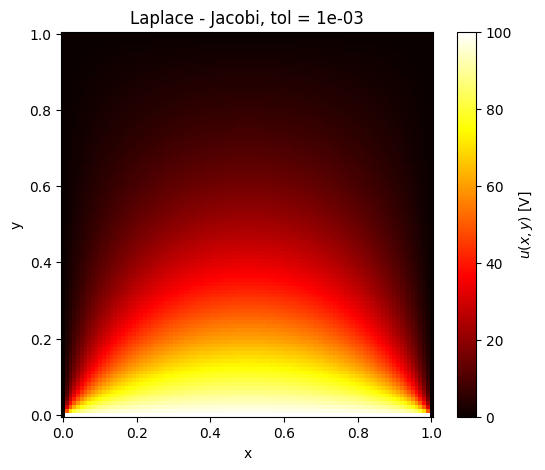

In [ ]:
plt.figure(figsize=(6, 5))
plt.pcolormesh(X,Y,V,shading="auto",cmap="hot")
plt.colorbar(label=r"$u(x,y)$ [V]")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Laplace - Jacobi, tol = {tol:.0e}")
plt.show()

Para aplicar diferencias finitas se uso practicamente la misma estrategia que la enseñada en clase, la única diferecia fue el cambio de numero de veces que se aplica la actualización a tolerancia. La tolerancia podemos pensarla como un epsilon que me indica cuál es el cambio entre dos iteraciones consecutivas. Mientras más pequeña sea  la tolerancia, significa que el código está convergiendo a algo. Para que en vez de poner N el código funcione con tolerancia. Podemos usar la tolerancia máxima de la matríz buscando el punto de máximo cambio en la iteración t= max(Vij(k+1) - Vij (k)). Se compara esta tolerancia con la deseada y se repite hasta que sea igual o menor.

In [ ]:
def un(x, y, n, L=1, V0=100):
    return (4*V0/(n*np.pi)* np.sin(n*np.pi*x/L)* np.sinh(n*np.pi*(L-y)/L)/ np.sinh(n*np.pi))

In [ ]:
def Fourier_solution(X, Y, Nterms, L=1, V0=100):
    U = np.zeros_like(X)
    for k in range(Nterms):
        n = 2*k + 1
        U += un(X,Y,n,L,V0)
    return U

In [ ]:
tol = 1e-4
Nmax = 100
L = 1
V0 = 100
ymin = L/(Nmax - 1)
for k in range(10000):
    n = 2*k + 1
    a = n*np.pi
    ratio = (
        np.exp(-a*ymin/L)* (1 - np.exp(-2*a*(1-ymin/L)))/ (1 - np.exp(-2*a)))
    error = (4*V0/(n*np.pi)* ratio)
    if error < tol:
        break
Nterms = k + 1
print("Numero de terminos =", Nterms)
print("Error =", error)

Numero de terminos = 134
Error = 9.97050546091076e-05


In [ ]:
U_fourier = Fourier_solution(X,Y,Nterms=134,L=1,V0=100)

/tmp/ipykernel_492/1409310366.py:2: RuntimeWarning: overflow encountered in sinh
  return (4*V0/(n*np.pi)* np.sin(n*np.pi*x/L)* np.sinh(n*np.pi*(L-y)/L)/ np.sinh(n*np.pi))
/tmp/ipykernel_492/1409310366.py:2: RuntimeWarning: invalid value encountered in multiply
  return (4*V0/(n*np.pi)* np.sin(n*np.pi*x/L)* np.sinh(n*np.pi*(L-y)/L)/ np.sinh(n*np.pi))
/tmp/ipykernel_492/1409310366.py:2: RuntimeWarning: invalid value encountered in divide
  return (4*V0/(n*np.pi)* np.sin(n*np.pi*x/L)* np.sinh(n*np.pi*(L-y)/L)/ np.sinh(n*np.pi))


In [ ]:
#Comparación entre las matrices resultantes de la serie y de las diferencias finitas
difference = np.abs(V - U_fourier)
difference

array([[           nan,            nan,            nan, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [           nan,            nan,            nan, ...,
        3.91969394e-03, 1.96078364e-03, 0.00000000e+00],
       [           nan,            nan,            nan, ...,
        7.83544699e-03, 3.91959584e-03, 0.00000000e+00],
       ...,
       [           nan,            nan,            nan, ...,
        7.83544699e-03, 3.91959584e-03, 0.00000000e+00],
       [           nan,            nan,            nan, ...,
        3.91969394e-03, 1.96078364e-03, 0.00000000e+00],
       [           nan,            nan,            nan, ...,
        8.62313090e-17, 4.30929790e-17, 0.00000000e+00]])

**SEGUNDA PARTE**

In [36]:
def solve_laplace(V, fixed, tol=1e-5, max_iter=100000):
    for iteration in range(max_iter):
        V_new = V.copy()
        V_new[1:-1, 1:-1] = 0.25 * (
            V[2:, 1:-1] +
            V[:-2, 1:-1] +
            V[1:-1, 2:] +
            V[1:-1, :-2])
        V_new[fixed] = V[fixed]
        error = np.max(np.abs(V_new - V))
        V = V_new
        if error < tol:
            break
    return V, iteration + 1

In [38]:
Nx = 200
Ny = 150
V0 = 100
V = np.zeros((Ny, Nx))
fixed = np.zeros_like(V, dtype=bool)
fixed[0, :] = True
fixed[-1, :] = True
fixed[:, 0] = True
fixed[:, -1] = True
ia = 80
ib = 120
j1 = 45
j2 = 105
V[j1:j2, ia] = +V0
V[j1:j2, ib] = -V0
fixed[j1:j2, ia] = True
fixed[j1:j2, ib] = True

In [39]:
V, iterations = solve_laplace(V,fixed,tol=1e-5)
print("Iteraciones:", iterations)


Iteraciones: 16196


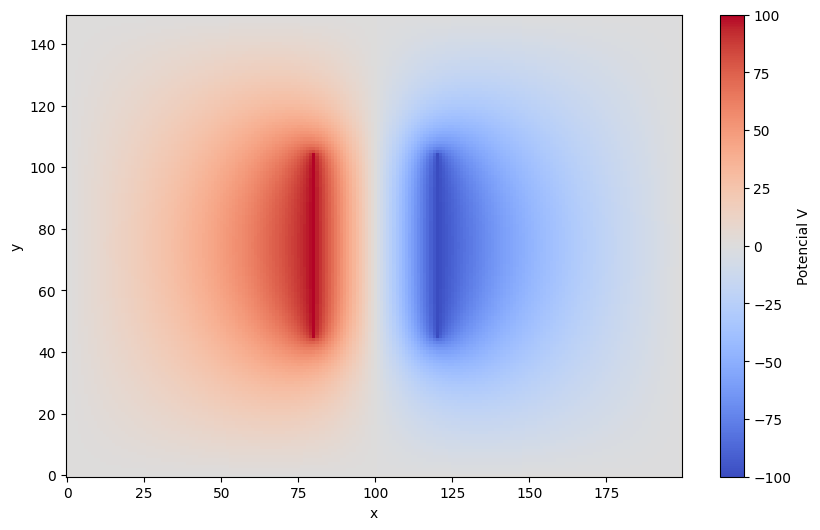

In [40]:
plt.figure(figsize=(10, 6))
plt.imshow(
    V,
    origin="lower",
    cmap="coolwarm")
plt.colorbar(label="Potencial V")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [41]:
def electric_field(V, dx=1, dy=1):
    Ex = np.zeros_like(V)
    Ey = np.zeros_like(V)
    # Interior: diferencias centrales
    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dx)
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dy)
    # Bordes: diferencias hacia adelante/atrás
    Ex[:, 0] = -(V[:, 1] - V[:, 0]) / dx
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dx
    Ey[0, :] = -(V[1, :] - V[0, :]) / dy
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dy
    return Ex, Ey

In [47]:
Lx = 10
Ly = 8
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
Ex, Ey = electric_field(V, dx, dy)
E = np.sqrt(Ex**2 + Ey**2)

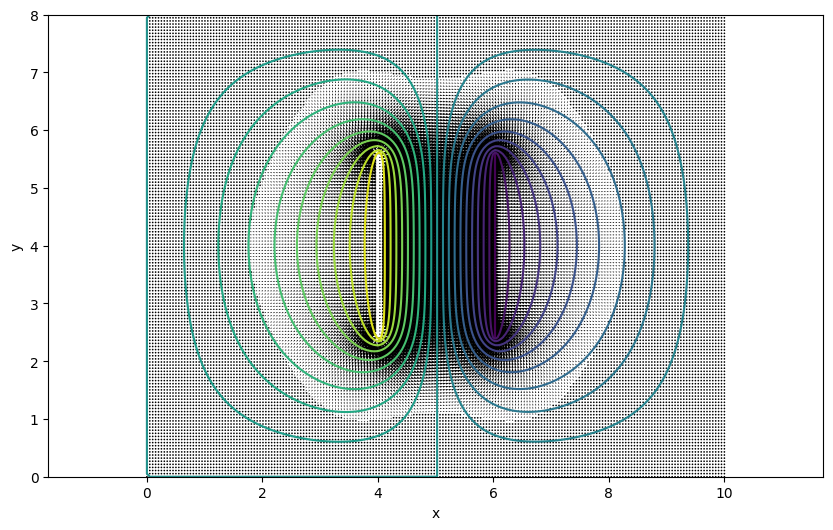

In [49]:
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)
plt.figure(figsize=(10, 6))
plt.contour(X, Y, V, levels=20)
plt.quiver(X,Y,Ex,Ey)
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()